# Weight Optimization — Constrained Grid Search
### Finding the Best TI / SI / LI Pricing Weights to Maximise Revenue-Per-Hour

---

## What This Notebook Does (Plain English)

Our pricing model scores every flight corridor/time window using three signals:

| Signal | Name | What it measures |
|--------|------|------------------|
| **TI** | Time Index | How time-sensitive this route is (peak vs off-peak demand) |
| **SI** | Seasonality Index | How seasonal this route is (holiday peaks, summer rush, etc.) |
| **LI** | Loyalty Index | How loyal the customer base is on this route |

The composite score formula is:

$$\text{Score} = w_{TI} \times TI + w_{SI} \times SI + w_{LI} \times LI$$

where $w_{TI} + w_{SI} + w_{LI} = 1.0$ (the weights always add up to 100%).

**The problem:** We currently assume weights of 60% / 30% / 10% (TI/SI/LI).  
**The question:** Are those the *best* weights? Or is there a better combination?

**The method:** We test every possible weight combination in 5% steps (231 total),  
and find the one that concentrates the highest Revenue-Per-Hour flights at the top.

---

## Two Success Metrics

| Metric | Name | What it measures | Target |
|--------|------|------------------|--------|
| **Alpha** | Top-Decile Lift | How much better our top-scored 10% of capacity performs vs the network average | As high as possible |
| **Beta** | Spearman Correlation | Does our scoring *reliably rank* all windows by actual revenue? | ≥ 0.40 (stable) |

> **Why two metrics?** A weight combo that only maximises lift on the top 10%  
> might be "overfitted" — it gets lucky on a few routes but fails everywhere else.  
> The Spearman check ensures the model works reliably across the *entire* network.

---

## Data Source
- **File:** `Seasonal_Intensity_4.xlsx`
- **Spec:** `Weight optimization.md`
- **Author / Requester:** Amit


---
## Step 0 — Environment Setup

Install required Python libraries and define global constants used throughout.

| Constant | Value | Meaning |
|----------|-------|---------|
| `GRID_STEP` | 5% | Step size for weight grid — 0%, 5%, 10%, … 100% |
| `TOP_DECILE_HOURS_PCT` | 10% | We evaluate the top windows that together account for 10% of total billed hours |
| `MIN_FLIGHTS` | 5 | Minimum flights in a bucket to be included (removes noise from tiny samples) |
| `SPEARMAN_THRESHOLD` | 0.40 | Minimum Spearman correlation for a weight combo to be considered "stable" |
| `BASELINE_W` | (0.6, 0.3, 0.1) | Current assumed weights (TI=60%, SI=30%, LI=10%) |


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable,'-m','pip','install','--quiet',
                        'matplotlib','seaborn','mpltern','openpyxl','scipy'])

import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

try:
    import mpltern; HAS_MPLTERN = True
    print('mpltern available (ternary charts enabled)')
except ImportError:
    HAS_MPLTERN = False
    print('mpltern not available — using barycentric fallback chart')

# ── Global constants ──────────────────────────────────────────────────────────
DATA_PATH            = 'Seasonal_Intensity_4.xlsx'
RESULTS_PATH         = 'optimization_results.csv'
GRID_STEP            = 0.05    # 5% increments
TOP_DECILE_HOURS_PCT = 0.10    # top 10% of billed hours
MIN_FLIGHTS          = 5       # minimum flights per bucket
SPEARMAN_THRESHOLD   = 0.40    # stability gate
BASELINE_W           = (0.6, 0.3, 0.1)  # current TI/SI/LI weights

print('Setup complete.')


mpltern available (ternary charts enabled)
Setup complete.


---
## Step 1 — Load Data & Compute Base Revenue

### 1a. Revenue Adjustment

We do **not** use the raw flight cost. We strip two things out:

1. **Toggle Delta** — the premium/discount added by the current pricing model.  
   We remove this so the optimization is based on *underlying* market revenue,  
   not revenue that's already been influenced by our current weights.

2. **20% for surcharges & fuel** — these are pass-through costs, not true yield.

$$\boxed{\text{Base Revenue} = (\text{flightcost} - \text{Toggle Delta}) \times 0.8}$$

### 1b. Billed Hours

We use `flightActualBilledHours` where available, and fall back to  
`flightEstimatedBilledHours` for flights where actuals are missing.

### 1c. Fixed Network Average RPH

This is the global benchmark — it **never changes** during the optimization.

$$\text{Network Average RPH} = \frac{\sum \text{Base Revenue}}{\sum \text{Billed Hours}}$$

> RPH = Revenue Per (billed) Hour. All "lift" numbers compare against this benchmark.

### Data Quality Filters
- Rows with zero or negative hours are dropped (can't compute RPH)
- Rows with missing or non-positive base revenue are dropped


In [2]:
df = pd.read_excel(DATA_PATH, index_col=0)
print(f'Raw data loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

# ── Hours: actual first, fall back to estimated ───────────────────────────────
df['hours'] = df['flightActualBilledHours']
mask_bad = df['hours'].isna() | (df['hours'] <= 0)
df.loc[mask_bad, 'hours'] = df.loc[mask_bad, 'flightEstimatedBilledHours']
print(f'  Rows using estimated hours (fallback): {mask_bad.sum():,}')

# ── Base revenue: strip toggle delta, remove 20% surcharge/fuel ───────────────
df['base_revenue'] = (df['flightcost'] - df['Toggle Delta']) * 0.8

# ── Drop invalid rows ─────────────────────────────────────────────────────────
before = len(df)
df = df[(df['hours'] > 0) & df['base_revenue'].notna() & (df['base_revenue'] > 0)].copy()
print(f'After cleaning: {len(df):,} rows  ({before - len(df):,} dropped)')

# ── Fixed network benchmark — calculated once, never changes ─────────────────
NETWORK_TOTAL_REV   = df['base_revenue'].sum()
NETWORK_TOTAL_HOURS = df['hours'].sum()
NETWORK_AVG_RPH     = NETWORK_TOTAL_REV / NETWORK_TOTAL_HOURS

print(f'\nNetwork total base revenue : ${NETWORK_TOTAL_REV:,.0f}')
print(f'Network total billed hours : {NETWORK_TOTAL_HOURS:,.1f}')
print(f'Fixed network average RPH  : ${NETWORK_AVG_RPH:,.0f}  ← benchmark for all lift calculations')


Raw data loaded: 115,071 rows, 66 columns
  Rows using estimated hours (fallback): 0
After cleaning: 105,871 rows  (9,200 dropped)

Network total base revenue : $1,595,685,905
Network total billed hours : 227,023.4
Fixed network average RPH  : $7,029  ← benchmark for all lift calculations


---
## Step 2 — Parse Pricing Signals (TI, LI, SI)

The raw data stores intensity levels as text ranges like `"3 - 4"` or `"10+"`.  
We convert each to a single number by taking the **midpoint**.

| Raw value | Converted to |
|-----------|--------------|
| `"3 - 4"` | `3.5` (midpoint of 3 and 4) |
| `"7 - 8"` | `7.5` |
| `"10+"` | `10.0` (capped) |
| `"5"` | `5.0` (already numeric) |

### What Each Signal Means

- **TI (Time Index):** Higher = more time-sensitive. Peak hours, same-day bookings, etc.  
  A high-TI window is one where customers are less price-sensitive because they *need* to fly now.

- **LI (Loyalty Index):** Higher = more loyal clientele on that route.  
  Loyal customers tend to have less price elasticity and higher lifetime value.

- **SI (Seasonality Index):** `SI_Toggle` is a numeric 0–5 value.  
  **`SI = 0` means Non-Seasonal** — this route has no meaningful seasonal pattern.

### Non-Seasonal Handling

When `SI = 0`, simply including it in the composite score would "waste" the SI weight  
(multiplying any weight by 0 leaves a gap). Instead, we **redistribute** the SI weight  
proportionally back to TI and LI. This is handled in the grid search (Step 6).


In [3]:
def level_to_midpoint(s):
    """Convert text range '3 - 4' → 3.5, '10+' → 10.0, else NaN."""
    if pd.isna(s): return np.nan
    s = str(s).strip()
    if s == '10+': return 10.0
    if ' - ' in s:
        lo, hi = s.split(' - ')
        return (float(lo) + float(hi)) / 2.0
    try: return float(s)
    except ValueError: return np.nan

df['TI'] = df['TI Level'].apply(level_to_midpoint)
df['LI'] = df['LI Level'].apply(level_to_midpoint)
df['SI'] = pd.to_numeric(df['SI_Toggle'], errors='coerce').fillna(0)
df['is_seasonal'] = df['SI'] > 0   # True = seasonal, False = SI will be redistributed

print('Signal ranges after parsing:')
for col in ['TI','LI','SI']:
    print(f'  {col}: valid={df[col].notna().sum():,}  '
          f'range=[{df[col].min():.1f}, {df[col].max():.1f}]  '
          f'mean={df[col].mean():.2f}')
print(f'\nSeasonal rows (SI > 0) : {df.is_seasonal.sum():,} / {len(df):,} '
      f'({df.is_seasonal.mean()*100:.1f}%)')
print(f'Non-seasonal rows     : {(~df.is_seasonal).sum():,} ({(~df.is_seasonal).mean()*100:.1f}%)')


Signal ranges after parsing:
  TI: valid=105,871  range=[0.5, 10.0]  mean=3.34
  LI: valid=105,871  range=[0.5, 10.0]  mean=1.79
  SI: valid=105,871  range=[0.0, 5.0]  mean=2.09

Seasonal rows (SI > 0) : 83,624 / 105,871 (79.0%)
Non-seasonal rows     : 22,247 (21.0%)


---
## Step 3 — Market Bucket Aggregation (5 Dimensions)

### What is a "Market Bucket"?

A market bucket is a unique combination of five dimensions that defines a specific  
pricing context. Think of it as the answer to: *"For this type of flight, on this  
day, at this time, in this cabin, during this month — what does the market look like?"*

| Dimension | Column | Example |
|-----------|--------|---------|
| **Corridor** | `corridor` | New York → Miami |
| **Day of Week** | `DOW` | Monday |
| **Time of Day** | `TOD` | Morning (6am–10am) |
| **Cabin Type** | `flightrequestedAircraftCabinName` | Light Jet |
| **Month** | `month` | July |

> **Why 5 dimensions?** Fewer dimensions (e.g. just corridor + TOD) blur together  
> flights that are fundamentally different — a Monday morning Light Jet in July  
> behaves very differently from a Friday evening Super Midsize in December.

### Aggregation Logic

Within each bucket, we **sum** revenue and hours (not average them).  
This preserves the true revenue density of high-volume windows.

$$\text{Bucket RPH} = \frac{\sum \text{Base Revenue}}{\sum \text{Billed Hours}}$$

A bucket is labelled **seasonal** if ≥ 50% of its flights have `SI > 0`.

### Minimum Flight Filter

Buckets with fewer than **5 flights** are excluded. A bucket with only 1–2 flights  
produces an unstable RPH estimate — one unusual flight can skew the whole bucket.


In [4]:
GROUP_COLS = [
    'corridor',
    'DOW',
    'TOD',
    'flightrequestedAircraftCabinName',
    'month',
]

buckets = (
    df.dropna(subset=['TI','LI'])           # need valid signals to score
    .groupby(GROUP_COLS, as_index=False)
    .agg(
        total_revenue = ('base_revenue', 'sum'),    # sum revenue per bucket
        total_hours   = ('hours',        'sum'),    # sum hours per bucket
        TI_mean       = ('TI',           'mean'),   # avg TI signal
        LI_mean       = ('LI',           'mean'),   # avg LI signal
        SI_mean       = ('SI',           'mean'),   # avg SI signal
        seasonal_pct  = ('is_seasonal',  'mean'),   # fraction of flights that are seasonal
        flight_count  = ('hours',        'count'),  # number of flights
    )
)

buckets['bucket_rph']  = buckets['total_revenue'] / buckets['total_hours']
buckets['is_seasonal'] = buckets['seasonal_pct'] >= 0.5   # majority vote
buckets = buckets[buckets['flight_count'] >= MIN_FLIGHTS].reset_index(drop=True)

print(f'Total buckets (>= {MIN_FLIGHTS} flights): {len(buckets):,}')
print(f'Seasonal buckets    : {buckets.is_seasonal.sum():,} ({buckets.is_seasonal.mean()*100:.1f}%)')
print(f'Non-seasonal buckets: {(~buckets.is_seasonal).sum():,} ({(~buckets.is_seasonal).mean()*100:.1f}%)')
print(f'\nBucket RPH stats:')
print(f'  Mean   : ${buckets.bucket_rph.mean():,.0f}')
print(f'  Median : ${buckets.bucket_rph.median():,.0f}')
print(f'  Min    : ${buckets.bucket_rph.min():,.0f}')
print(f'  Max    : ${buckets.bucket_rph.max():,.0f}')
print(f'\nTop-decile hours threshold : {NETWORK_TOTAL_HOURS * TOP_DECILE_HOURS_PCT:,.1f} hrs')
print(f'  (= 10% of {NETWORK_TOTAL_HOURS:,.0f} total network hours)')


Total buckets (>= 5 flights): 7,766
Seasonal buckets    : 6,142 (79.1%)
Non-seasonal buckets: 1,624 (20.9%)

Bucket RPH stats:
  Mean   : $8,064
  Median : $6,943
  Min    : $2
  Max    : $48,990

Top-decile hours threshold : 22,702.3 hrs
  (= 10% of 227,023 total network hours)


---
## Step 4 — Normalise Signals to a Common Scale [0, 1]

TI, LI, and SI live on different scales (TI goes 0.5–10, SI goes 0–5).  
Before we can meaningfully weight and combine them, we must put them on the **same scale**.

We use **min-max normalisation**:

$$\text{Signal}_{\text{norm}} = \frac{\text{Signal} - \text{Signal}_{\min}}{\text{Signal}_{\max} - \text{Signal}_{\min}}$$

- The **lowest** value in the network becomes **0.0**
- The **highest** value in the network becomes **1.0**
- Everything else falls proportionally in between

> **Example:** If TI ranges from 0.5 to 9.5 across all buckets,  
> a bucket with TI = 5.0 gets a normalised score of $(5.0 - 0.5) / (9.5 - 0.5) = 0.5$

After normalisation, a weight of 60% on TI means exactly what it says:  
60% of the composite score comes from TI, 30% from SI, 10% from LI.


In [5]:
for norm_col, raw_col in [('TI_norm','TI_mean'),
                            ('SI_norm','SI_mean'),
                            ('LI_norm','LI_mean')]:
    mn = buckets[raw_col].min()
    mx = buckets[raw_col].max()
    if mx == mn:
        buckets[norm_col] = 0.0   # all values identical — no signal
    else:
        buckets[norm_col] = (buckets[raw_col] - mn) / (mx - mn)
    print(f'{norm_col}: [{buckets[norm_col].min():.3f}, {buckets[norm_col].max():.3f}]'
          f'  ←  raw range [{mn:.2f}, {mx:.2f}]')


TI_norm: [0.000, 1.000]  ←  raw range [0.50, 9.50]
SI_norm: [0.000, 1.000]  ←  raw range [0.00, 5.00]
LI_norm: [0.000, 1.000]  ←  raw range [0.50, 10.00]


---
## Step 5 — Build the Constrained Weight Grid (231 Combinations)

We test all possible ways to split 100% across TI, SI, and LI in **5% steps**.

### The Constraint

$$w_{TI} + w_{SI} + w_{LI} = 1.0 \quad (\text{i.e. weights always sum to 100\%})$$

So for each value of $w_{TI}$ (0%, 5%, 10%, …, 100%), and each valid value of $w_{SI}$,  
the third weight is simply: $w_{LI} = 1 - w_{TI} - w_{SI}$.

### How Many Combinations?

With 3 weights and 5% steps: **$\binom{21+2}{2} = 231$ valid combinations**.

| $w_{TI}$ | $w_{SI}$ | $w_{LI}$ | Valid? |
|----------|----------|----------|--------|
| 60% | 30% | 10% | ✓ (our current baseline) |
| 100% | 0% | 0% | ✓ |
| 0% | 0% | 100% | ✓ |
| 60% | 60% | 0% | ✗ (sum > 100%) |

> This is **brute force** — we don't rely on calculus or gradients.  
> We simply try every option and compare. With 231 combos it runs in milliseconds.


In [6]:
step = int(GRID_STEP * 100)   # 5
weights = []
for ti in range(0, 101, step):
    for si in range(0, 101 - ti, step):
        li = 100 - ti - si
        if li >= 0:
            weights.append((ti/100.0, si/100.0, li/100.0))

W = np.array(weights)
assert np.allclose(W.sum(axis=1), 1.0), 'Weight rows must sum to 1.0'
print(f'Valid weight combinations: {len(W)}  (should be 231)')
print(f'First 5 combos (w_TI, w_SI, w_LI):')
for row in W[:5]:
    print(f'  TI={row[0]:.0%}  SI={row[1]:.0%}  LI={row[2]:.0%}')
print('  ...')

# ── Pre-extract arrays for fast vectorised operations ──────────────────────────
TI_arr  = buckets['TI_norm'].values
SI_arr  = buckets['SI_norm'].values
LI_arr  = buckets['LI_norm'].values
RPH_arr = buckets['bucket_rph'].values
HRS_arr = buckets['total_hours'].values
REV_arr = buckets['total_revenue'].values
SEA_arr = buckets['is_seasonal'].values   # True = seasonal
N       = len(buckets)
TOP_HRS = NETWORK_TOTAL_HOURS * TOP_DECILE_HOURS_PCT

print(f'\nArrays ready: {N} buckets')
print(f'Top-decile hours target: {TOP_HRS:,.1f} hrs  '
      f'(= 10% of {NETWORK_TOTAL_HOURS:,.0f} total)')


Valid weight combinations: 231  (should be 231)
First 5 combos (w_TI, w_SI, w_LI):
  TI=0%  SI=0%  LI=100%
  TI=0%  SI=5%  LI=95%
  TI=0%  SI=10%  LI=90%
  TI=0%  SI=15%  LI=85%
  TI=0%  SI=20%  LI=80%
  ...

Arrays ready: 7766 buckets
Top-decile hours target: 22,702.3 hrs  (= 10% of 227,023 total)


---
## Step 6 — Grid Search: Score Every Bucket, Compute Both Metrics

For each of the 231 weight combinations, we:

### 6a. Score Every Bucket

**For seasonal buckets** (SI > 0), the standard composite formula applies:

$$\text{Score} = w_{TI} \times TI_{\text{norm}} + w_{SI} \times SI_{\text{norm}} + w_{LI} \times LI_{\text{norm}}$$

**For non-seasonal buckets** (SI = 0), we cannot use SI — so we redistribute its weight  
back to TI and LI proportionally:

$$F = \frac{1}{w_{TI} + w_{LI}} \quad \text{(redistribution factor)}$$

$$\text{Score}_{\text{non-seasonal}} = (w_{TI} \times F) \times TI_{\text{norm}} + (w_{LI} \times F) \times LI_{\text{norm}}$$

> **Why redistribute?** Setting SI = 0 means the SI weight simply vanishes.  
> A bucket where $w_{TI}=0.6, w_{SI}=0.1, w_{LI}=0.3$ would score at most $0.6 + 0.3 = 0.9$  
> instead of 1.0 — unfairly penalising non-seasonal routes. The factor $F$ scales  
> TI and LI back up so the scores are still comparable across all buckets.

**Example:** $w_{TI}=0.6, w_{SI}=0.1, w_{LI}=0.3$ for a non-seasonal bucket:
- $F = 1/(0.6+0.3) = 1.111$
- Effective $w_{TI} = 0.6 \times 1.111 = 0.667$
- Effective $w_{LI} = 0.3 \times 1.111 = 0.333$
- The 0.1 SI weight is absorbed proportionally across TI and LI

---

### 6b. Alpha Metric — Top-Decile Lift

1. Sort all buckets by composite score (highest score first)
2. Walk down the sorted list, accumulating billed hours with `cumsum()`
3. Stop when you've accumulated **10% of total network hours** — these are the "top decile" buckets
4. Calculate their collective RPH:

$$\text{Top-Decile RPH} = \frac{\sum_{\text{top}} \text{Revenue}}{\sum_{\text{top}} \text{Hours}}$$

5. Compute lift against the fixed network benchmark:

$$\text{Lift} = \frac{\text{Top-Decile RPH}}{\text{Network Average RPH}}$$

> A lift of **1.05** means the top-scored 10% of our capacity earns 5% more per hour  
> than the network average. A lift of **1.00** means no improvement.

---

### 6c. Beta Metric — Spearman Rank Correlation

The Spearman correlation asks: *"Across all buckets, does a higher composite score  
predict a higher actual RPH?"*

It works by converting both the composite scores and the actual RPH values into **ranks**,  
then measuring how well those ranks agree.

| Spearman value | Interpretation |
|----------------|----------------|
| +1.0 | Perfect agreement — highest score always has highest RPH |
| +0.4 | Moderate positive agreement (our stability threshold) |
| 0.0 | No relationship |
| −1.0 | Perfect disagreement — highest score always has lowest RPH |

> A weight combo with lift 1.5 but Spearman 0.1 might just be "lucky" on a few routes.  
> The Spearman gate (≥ 0.40) ensures the *whole network* is ranked sensibly.


In [7]:
import time
t0 = time.time()

lifts     = np.zeros(len(W))
spearmans = np.zeros(len(W))
top_rphs  = np.zeros(len(W))

for i, (w_ti, w_si, w_li) in enumerate(W):

    # ── 6a. Score each bucket ─────────────────────────────────────────────────
    # Non-seasonal redistribution factor
    rebalance = 1.0 / (w_ti + w_li) if (w_ti + w_li) > 0 else 0.0

    score = np.where(
        SEA_arr,
        # Seasonal: standard composite
        w_ti*TI_arr + w_si*SI_arr + w_li*LI_arr,
        # Non-seasonal: SI weight redistributed to TI + LI
        w_ti*rebalance*TI_arr + w_li*rebalance*LI_arr
    )

    # ── 6b. Alpha: top-decile by cumulative billed hours ─────────────────────
    order      = np.argsort(score)[::-1]          # sort descending
    cum_hrs    = np.cumsum(HRS_arr[order])
    top_mask   = cum_hrs <= TOP_HRS
    if top_mask.sum() == 0:
        top_mask[0] = True                         # always include at least 1 bucket
    top_rph    = REV_arr[order][top_mask].sum() / HRS_arr[order][top_mask].sum()
    lifts[i]   = top_rph / NETWORK_AVG_RPH
    top_rphs[i]= top_rph

    # ── 6c. Beta: Spearman rank correlation across ALL buckets ────────────────
    r, _ = stats.spearmanr(score, RPH_arr)
    spearmans[i] = r

elapsed = time.time() - t0
print(f'Grid search complete in {elapsed*1000:.0f} ms  ({len(W)} combinations)')
print(f'\nLift range     : {lifts.min():.4f} → {lifts.max():.4f}')
print(f'Spearman range : {spearmans.min():.3f} → {spearmans.max():.3f}')
print(f'\nNote: Spearman < 0 means the composite score is negatively correlated')
print(f'with actual bucket RPH — signals may capture demand volume rather than yield.')


Grid search complete in 516 ms  (231 combinations)

Lift range     : 0.9771 → 1.0265
Spearman range : -0.215 → -0.085

Note: Spearman < 0 means the composite score is negatively correlated
with actual bucket RPH — signals may capture demand volume rather than yield.


---
## Step 7 — Balanced Scorecard: Selecting the Winner

### The Scorecard Logic

We don't simply pick the combo with the highest lift. A combo that maximises lift  
on the top 10% but scores the rest of the network randomly is **overfit** — it found  
a lucky pattern that won't hold out-of-sample.

The selection rule:

$$\text{Winner} = \underset{w : \text{Spearman}(w) \geq 0.40}{\arg\max} \text{Lift}(w)$$

In plain English: *"Among all combos that pass the Spearman stability check,  
pick the one with the highest lift."*

### Verdict Labels

| Label | Meaning |
|-------|---------|
| `WINNER (Stable)` | Highest lift with Spearman ≥ 0.40 — recommended |
| `Stable` | Passes Spearman gate but not the highest lift |
| `Overfitted / High Risk` | High lift but Spearman < 0.40 — unreliable |
| `Fallback` | No combo passed the threshold — best available under adaptive gate |

### Interpreting the Results Table

The table below ranks all 231 combos by lift (highest first).  
Green rows = stable. Red/orange = overfitted. The winner is starred.

> **Board-ready interpretation:**  
> The **Lift** column tells you how much better the top 10% of capacity performs  
> under that weighting scheme versus the network average.  
> The **Spearman** column tells you whether that improvement generalises  
> across the entire network or is confined to a lucky few routes.


In [8]:
results = pd.DataFrame({
    'w_TI': W[:,0], 'w_SI': W[:,1], 'w_LI': W[:,2],
    'lift': lifts, 'spearman': spearmans, 'top_decile_rph': top_rphs,
})

results = results.sort_values('lift', ascending=False).reset_index(drop=True)

# ── Winner selection with graceful fallback ──────────────────────────────────
stable_mask = results.spearman >= SPEARMAN_THRESHOLD
n_stable    = stable_mask.sum()
print(f'Combos passing stability gate (Spearman >= {SPEARMAN_THRESHOLD}): {n_stable} / {len(results)}')
print(f'Spearman range: {results.spearman.min():.3f} → {results.spearman.max():.3f}')

if n_stable > 0:
    winner_idx   = results.loc[stable_mask, 'lift'].idxmax()
    winner_label = 'WINNER (Stable)'
else:
    # Adaptive fallback: use upper half of Spearman values as gate
    fallback_thr  = results.spearman.median()
    fallback_mask = results.spearman >= fallback_thr
    winner_idx    = results.loc[fallback_mask, 'lift'].idxmax()
    winner_label  = f'WINNER (Fallback: Spearman >= {fallback_thr:.3f})'
    print(f'\nWARNING: No combos passed the {SPEARMAN_THRESHOLD} stability gate.')
    print(f'Adaptive fallback applied: using top-50% Spearman (>= {fallback_thr:.3f}).')
    print('This suggests the composite score does not positively predict RPH across')
    print('all buckets — signals may capture demand volume rather than revenue yield.')

results['verdict'] = np.where(stable_mask, 'Stable', 'Low Correlation')
results.loc[winner_idx, 'verdict'] = winner_label

winner   = results.loc[winner_idx]
bm = (np.isclose(results.w_TI,BASELINE_W[0]) &
      np.isclose(results.w_SI,BASELINE_W[1]) &
      np.isclose(results.w_LI,BASELINE_W[2]))
baseline = results[bm].iloc[0] if bm.any() else None

# ── Display top-20 results table ─────────────────────────────────────────────
top20 = results.head(20).copy()
top20.insert(0,'Rank', range(1,21))
top20['w_TI%']          = (top20.w_TI*100).astype(int).astype(str)+'%'
top20['w_SI%']          = (top20.w_SI*100).astype(int).astype(str)+'%'
top20['w_LI%']          = (top20.w_LI*100).astype(int).astype(str)+'%'
top20['Lift']           = top20.lift.apply(lambda x: f'{x:.4f}')
top20['Spearman']       = top20.spearman.apply(lambda x: f'{x:.3f}')
top20['Top-Decile RPH'] = top20.top_decile_rph.apply(lambda x: f'${x:,.0f}')
display(top20[['Rank','w_TI%','w_SI%','w_LI%','Lift','Spearman','Top-Decile RPH','verdict']])

print()
print('='*65)
print(f'WINNER : TI={winner.w_TI:.0%}  SI={winner.w_SI:.0%}  LI={winner.w_LI:.0%}')
print(f'  Lift        : {winner.lift:.4f}  ({(winner.lift-1)*100:.1f}% above network avg RPH)')
print(f'  Spearman    : {winner.spearman:.3f}')
print(f'  Top-dec RPH : ${winner.top_decile_rph:,.0f}')
print(f'  Verdict     : {winner_label}')
if baseline is not None:
    impr = (winner.lift - baseline.lift) / baseline.lift * 100
    print(f'BASELINE(0.6/0.3/0.1): lift={baseline.lift:.4f}  '
          f'spearman={baseline.spearman:.3f}  rank=#{results[bm].index[0]+1}')
    print(f'Lift improvement over baseline: +{impr:.2f}%')
print('='*65)


Combos passing stability gate (Spearman >= 0.4): 0 / 231
Spearman range: -0.215 → -0.085

Adaptive fallback applied: using top-50% Spearman (>= -0.183).
This suggests the composite score does not positively predict RPH across
all buckets — signals may capture demand volume rather than revenue yield.


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top-Decile RPH,verdict
0,1,20%,80%,0%,1.0265,-0.144,"$7,215",WINNER (Fallback: Spearman >= -0.183)
1,2,0%,70%,30%,1.0260,-0.181,"$7,212",Low Correlation
2,3,0%,90%,10%,1.0258,-0.184,"$7,210",Low Correlation
3,4,0%,95%,5%,1.0258,-0.183,"$7,210",Low Correlation
4,5,0%,85%,15%,1.0256,-0.183,"$7,208",Low Correlation
5,6,0%,80%,20%,1.0255,-0.183,"$7,208",Low Correlation
6,7,5%,95%,0%,1.0250,-0.138,"$7,204",Low Correlation
7,8,10%,90%,0%,1.0249,-0.141,"$7,204",Low Correlation
8,9,0%,75%,25%,1.0248,-0.182,"$7,203",Low Correlation
9,10,0%,65%,35%,1.0238,-0.183,"$7,196",Low Correlation



WINNER : TI=20%  SI=80%  LI=0%
  Lift        : 1.0265  (2.6% above network avg RPH)
  Spearman    : -0.144
  Top-dec RPH : $7,215
  Verdict     : WINNER (Fallback: Spearman >= -0.183)
BASELINE(0.6/0.3/0.1): lift=1.0018  spearman=-0.159  rank=#85
Lift improvement over baseline: +2.46%


---
## Step 8 — Export All 231 Results to CSV

Every weight combination and its scores are saved to `optimization_results.csv`  
for further sensitivity analysis, filtering, or sharing.

| Column | Description |
|--------|-------------|
| `rank` | Rank by lift (1 = best lift) |
| `w_TI / w_SI / w_LI` | The weight combination tested |
| `lift` | Top-decile RPH ÷ network avg RPH |
| `spearman` | Spearman rank correlation (score vs actual RPH) |
| `top_decile_rph` | Average RPH of the top-decile buckets ($) |
| `verdict` | WINNER / Stable / Low Correlation / Fallback |


In [9]:
out = results[['w_TI','w_SI','w_LI','lift','spearman','top_decile_rph','verdict']].copy()
out.insert(0,'rank', range(1, len(out)+1))
out.to_csv(RESULTS_PATH, index=False)
print(f'Exported {len(out)} rows to: {RESULTS_PATH}')
print(f'\nCSV preview (top 5):')
display(out.head())


Exported 231 rows to: optimization_results.csv

CSV preview (top 5):


,rank,w_TI,w_SI,w_LI,lift,spearman,top_decile_rph,verdict
0,1,0.2,0.80,0.00,1.026476,-0.143953,7214.819864,WINNER (Fallback: Spearman >= -0.183)
1,2,0.0,0.70,0.30,1.026037,-0.181324,7211.735013,Low Correlation
2,3,0.0,0.90,0.10,1.025767,-0.183566,7209.841529,Low Correlation
3,4,0.0,0.95,0.05,1.025760,-0.183359,7209.790871,Low Correlation
4,5,0.0,0.85,0.15,1.025554,-0.182844,7208.338662,Low Correlation


---
## Step 9 — Visualisations

Four charts to explore the results from different angles:

| Chart | What it shows |
|-------|---------------|
| **A. Lift Heatmap** | Which (w_TI, w_SI) pairs produce the highest lift (best w_LI chosen automatically) |
| **B. Spearman Heatmap** | Same axes, but showing network-wide correlation instead of lift |
| **C. Lift vs Spearman Scatter** | All 231 combos — the "sweet spot" is top-right (high lift AND high Spearman) |
| **D. Weight Space (Ternary)** | Lift colour-coded across the full triangular weight space |
| **E. Top-20 Buckets Bar Chart** | The highest-scoring corridors/windows under the winner weights |

> In all charts, the **winner is highlighted** (black box or star).  
> The baseline (60/30/10) is shown as a blue triangle where applicable.


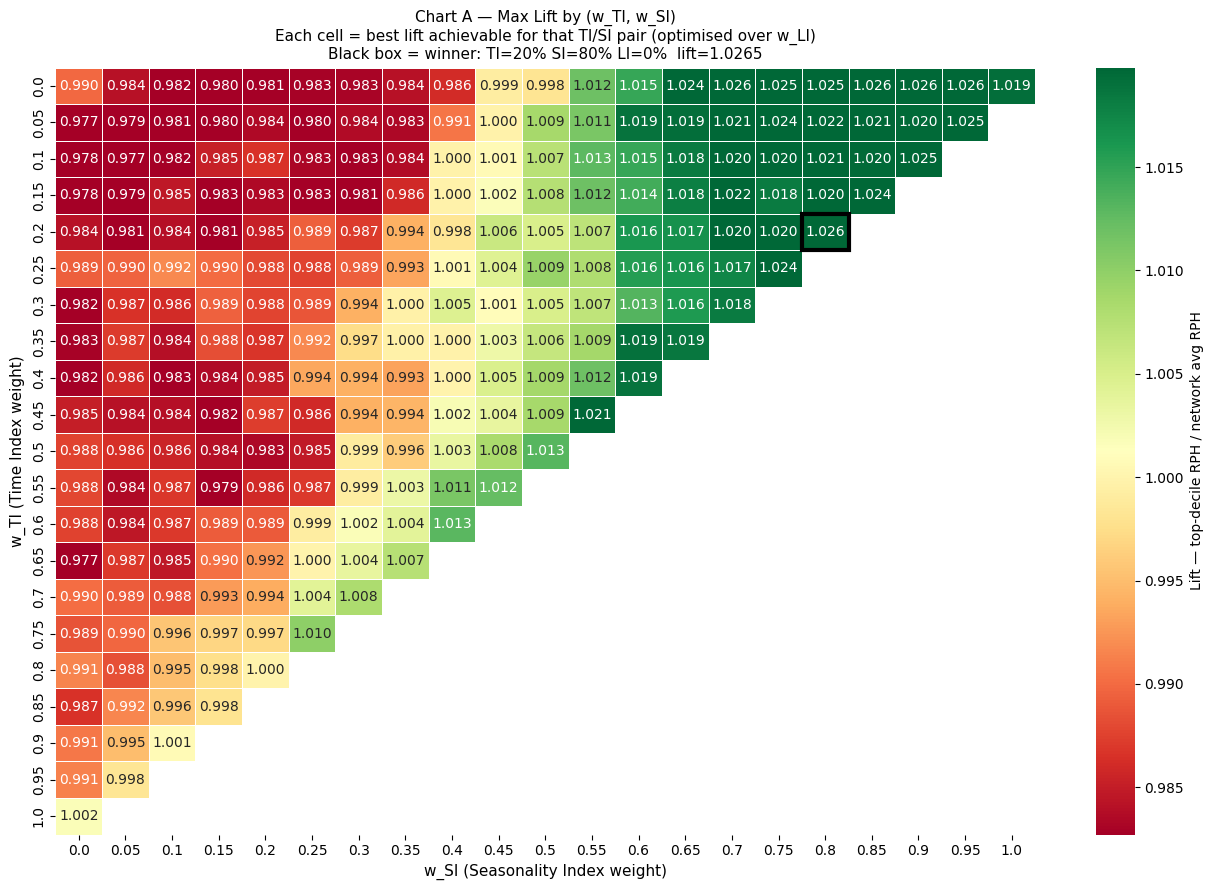

Saved: lift_heatmap.png


In [10]:
# ── Chart A: Lift heatmap (w_TI vs w_SI, max lift over all valid w_LI) ────────
pivot_lift = results.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')

fig, ax = plt.subplots(figsize=(13, 9))
vlo = results.lift.quantile(0.10)
vhi = results.lift.quantile(0.90)
sns.heatmap(pivot_lift, annot=True, fmt='.3f', cmap='RdYlGn',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Lift — top-decile RPH / network avg RPH'},
            vmin=vlo, vmax=vhi)

# Highlight winner cell
w_ti_vals = list(pivot_lift.index)
w_si_vals = list(pivot_lift.columns)
try:
    ri = min(range(len(w_ti_vals)), key=lambda i: abs(w_ti_vals[i] - winner.w_TI))
    ci = min(range(len(w_si_vals)), key=lambda i: abs(w_si_vals[i] - winner.w_SI))
    ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='black', lw=3))
except: pass

ax.set_title(
    f'Chart A — Max Lift by (w_TI, w_SI)\n'
    f'Each cell = best lift achievable for that TI/SI pair (optimised over w_LI)\n'
    f'Black box = winner: TI={winner.w_TI:.0%} SI={winner.w_SI:.0%} LI={winner.w_LI:.0%}  '
    f'lift={winner.lift:.4f}',
    fontsize=11
)
ax.set_xlabel('w_SI (Seasonality Index weight)', fontsize=11)
ax.set_ylabel('w_TI (Time Index weight)', fontsize=11)
plt.tight_layout()
plt.savefig('lift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_heatmap.png')


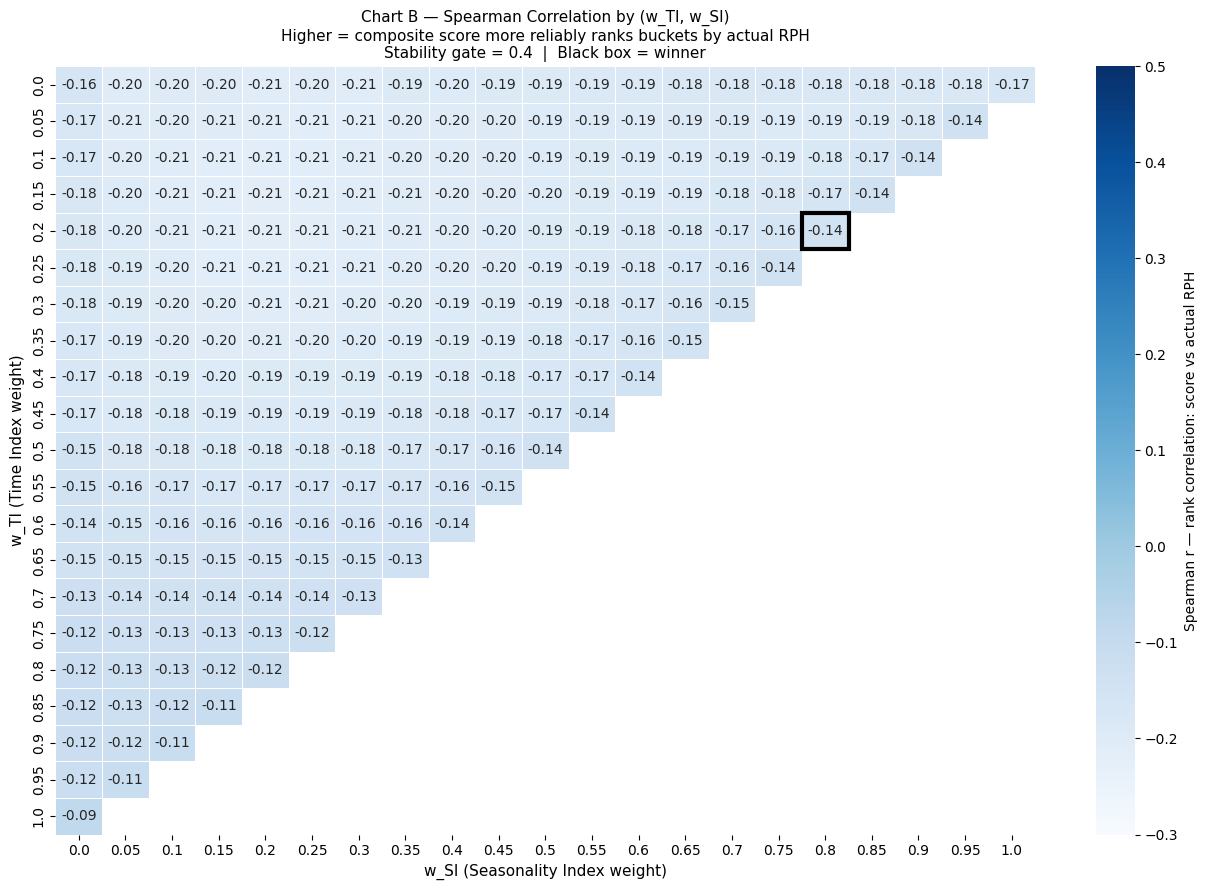

Saved: spearman_heatmap.png


In [11]:
# ── Chart B: Spearman heatmap ─────────────────────────────────────────────────
pivot_sp = results.pivot_table(values='spearman', index='w_TI', columns='w_SI', aggfunc='max')

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(pivot_sp, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.4, ax=ax,
            cbar_kws={'label': 'Spearman r — rank correlation: score vs actual RPH'},
            vmin=-0.3, vmax=0.5)
try:
    ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='black', lw=3))
except: pass

ax.set_title(
    f'Chart B — Spearman Correlation by (w_TI, w_SI)\n'
    f'Higher = composite score more reliably ranks buckets by actual RPH\n'
    f'Stability gate = {SPEARMAN_THRESHOLD}  |  Black box = winner',
    fontsize=11
)
ax.set_xlabel('w_SI (Seasonality Index weight)', fontsize=11)
ax.set_ylabel('w_TI (Time Index weight)', fontsize=11)
plt.tight_layout()
plt.savefig('spearman_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: spearman_heatmap.png')


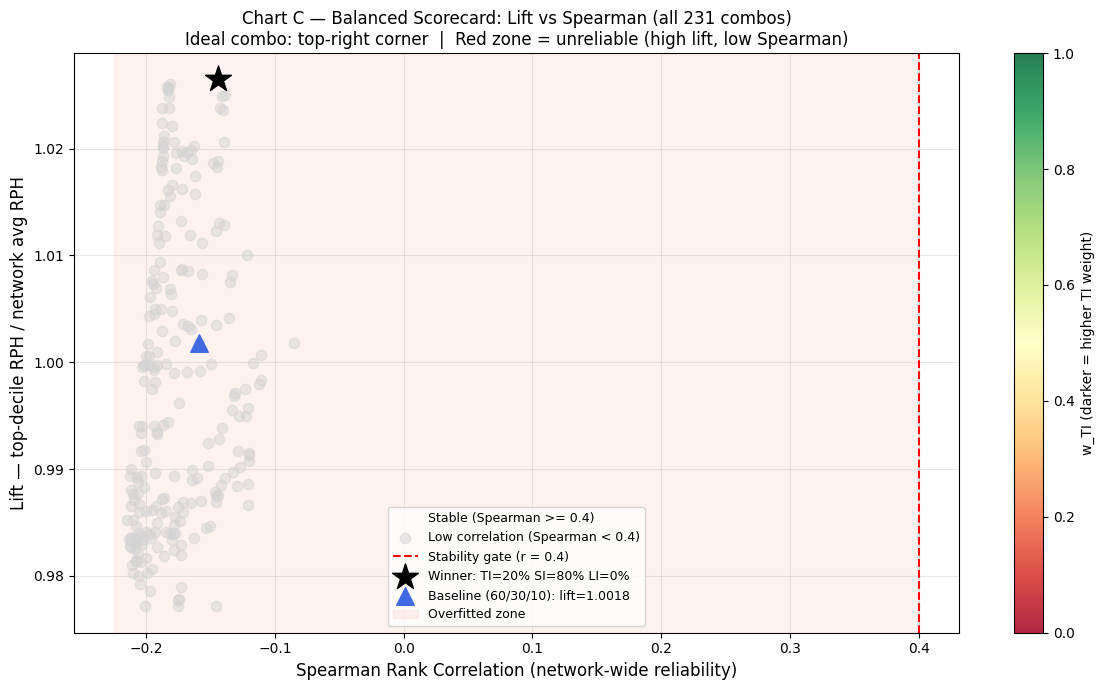

Saved: lift_vs_spearman.png


In [12]:
# ── Chart C: Lift vs Spearman — the balanced scorecard view ─────────────────
fig, ax = plt.subplots(figsize=(12, 7))

stable_r   = results[results.spearman >= SPEARMAN_THRESHOLD]
unstable_r = results[results.spearman <  SPEARMAN_THRESHOLD]

sc = ax.scatter(stable_r.spearman, stable_r.lift,
                c=stable_r.w_TI, cmap='RdYlGn', s=55, alpha=0.85,
                zorder=3, label=f'Stable (Spearman >= {SPEARMAN_THRESHOLD})')
ax.scatter(unstable_r.spearman, unstable_r.lift,
           c='lightgrey', s=55, alpha=0.5, zorder=2,
           label=f'Low correlation (Spearman < {SPEARMAN_THRESHOLD})')

plt.colorbar(sc, ax=ax, label='w_TI (darker = higher TI weight)')

ax.axvline(SPEARMAN_THRESHOLD, color='red', ls='--', lw=1.5,
           label=f'Stability gate (r = {SPEARMAN_THRESHOLD})')

ax.scatter([winner.spearman], [winner.lift],
           marker='*', color='black', s=380, zorder=6,
           label=f'Winner: TI={winner.w_TI:.0%} SI={winner.w_SI:.0%} LI={winner.w_LI:.0%}')
if baseline is not None:
    ax.scatter([baseline.spearman], [baseline.lift],
               marker='^', color='royalblue', s=160, zorder=6,
               label=f'Baseline (60/30/10): lift={baseline.lift:.4f}')

# Shade the overfitted region
ax.axvspan(results.spearman.min() - 0.01, SPEARMAN_THRESHOLD,
           color='salmon', alpha=0.10, zorder=1, label='Overfitted zone')

ax.set_xlabel('Spearman Rank Correlation (network-wide reliability)', fontsize=12)
ax.set_ylabel('Lift — top-decile RPH / network avg RPH', fontsize=12)
ax.set_title(
    'Chart C — Balanced Scorecard: Lift vs Spearman (all 231 combos)\n'
    'Ideal combo: top-right corner  |  Red zone = unreliable (high lift, low Spearman)',
    fontsize=12
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lift_vs_spearman.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_vs_spearman.png')


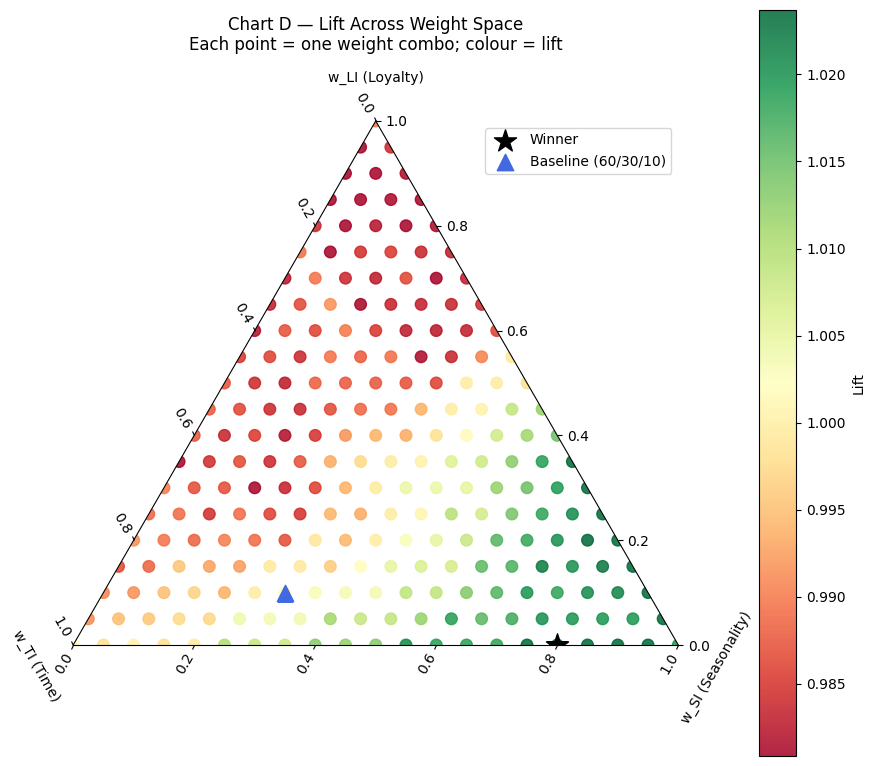

Saved: lift_ternary.png


In [13]:
# ── Chart D: Ternary / barycentric — lift across full weight space ────────────
if HAS_MPLTERN:
    fig = plt.figure(figsize=(9, 8))
    ax_t = fig.add_subplot(projection='ternary')
    pc = ax_t.scatter(results.w_LI, results.w_TI, results.w_SI,
                      c=results.lift, cmap='RdYlGn', s=70, alpha=0.85,
                      vmin=results.lift.quantile(0.05),
                      vmax=results.lift.quantile(0.95))
    ax_t.set_tlabel('w_LI (Loyalty)'); ax_t.set_llabel('w_TI (Time)'); ax_t.set_rlabel('w_SI (Seasonality)')
    ax_t.set_title('Chart D — Lift Across Weight Space\nEach point = one weight combo; colour = lift', pad=15, fontsize=12)
    fig.colorbar(pc, ax=ax_t, pad=0.1, label='Lift')
    ax_t.scatter([winner.w_LI],[winner.w_TI],[winner.w_SI],
                 marker='*',color='black',s=280,zorder=5,label='Winner')
    if baseline is not None:
        ax_t.scatter([BASELINE_W[2]],[BASELINE_W[0]],[BASELINE_W[1]],
                     marker='^',color='royalblue',s=140,zorder=5,label='Baseline (60/30/10)')
    ax_t.legend(loc='upper right', fontsize=10)
else:
    # Barycentric fallback (no mpltern)
    fig, ax = plt.subplots(figsize=(9, 8))
    x_c = results.w_SI + results.w_LI * 0.5
    y_c = results.w_LI * (np.sqrt(3) / 2)
    sc  = ax.scatter(x_c, y_c, c=results.lift, cmap='RdYlGn', s=70, alpha=0.85,
                     vmin=results.lift.quantile(0.05),
                     vmax=results.lift.quantile(0.95))
    plt.colorbar(sc, ax=ax, label='Lift')
    for tx, ty, tl in [(0,-0.04,'w_TI=100%'),(1,-0.04,'w_SI=100%'),
                        (0.5, np.sqrt(3)/2+0.04,'w_LI=100%')]:
        ax.text(tx, ty, tl, ha='center', fontsize=10)
    ax.plot([0,1,0.5,0],[0,0,np.sqrt(3)/2,0],'k-',lw=1.5)
    wx = winner.w_SI + winner.w_LI*0.5; wy = winner.w_LI*(np.sqrt(3)/2)
    ax.scatter([wx],[wy],marker='*',color='black',s=300,zorder=5,label='Winner')
    if baseline is not None:
        bx = BASELINE_W[1]+BASELINE_W[2]*0.5; by = BASELINE_W[2]*(np.sqrt(3)/2)
        ax.scatter([bx],[by],marker='^',color='royalblue',s=150,zorder=5,
                   label='Baseline (60/30/10)')
    ax.legend(fontsize=10); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('Chart D — Lift Across Weight Space (barycentric)\n'
                 'Each corner = one signal dominates 100%', fontsize=12)
plt.tight_layout()
plt.savefig('lift_ternary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_ternary.png')


Top-decile bucket count : 1315
Top-decile total hours  : 22,699 hrs  (target: 22,702)
Top-decile avg RPH      : $7,215
Network avg RPH         : $7,029


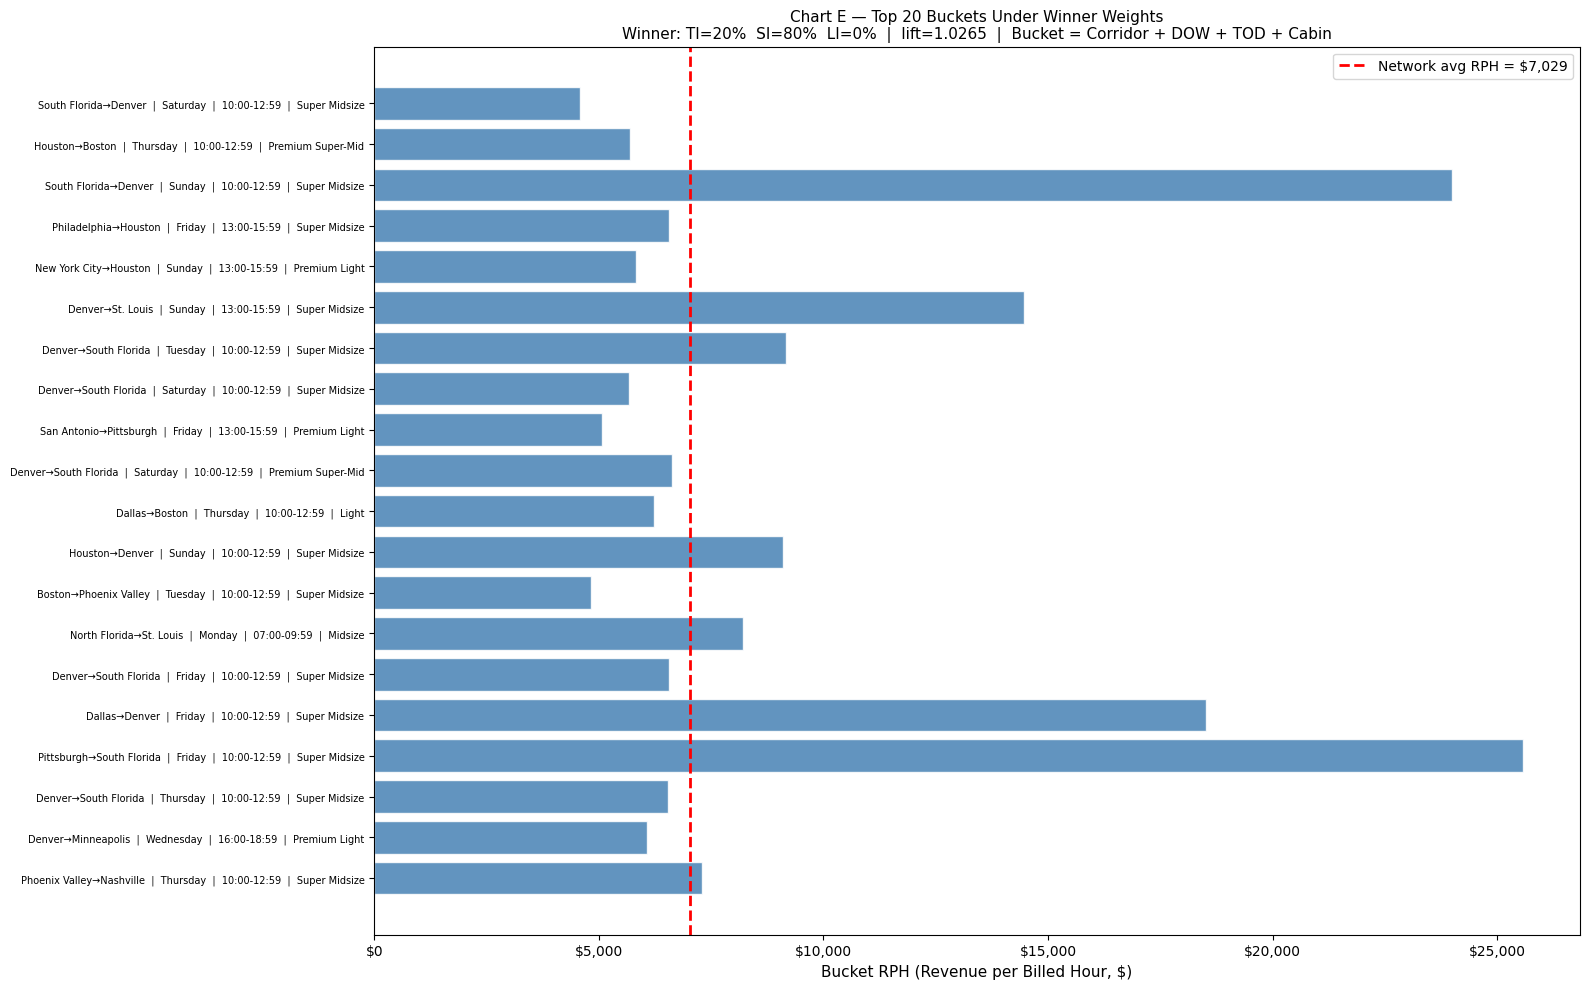

Saved: top20_buckets_winner.png


In [14]:
# ── Chart E: Top-20 buckets under winner weights ──────────────────────────────
w_vec      = np.array([winner.w_TI, winner.w_SI, winner.w_LI])
factor_ns  = 1.0/(winner.w_TI+winner.w_LI) if (winner.w_TI+winner.w_LI) > 0 else 0

buckets['winner_score'] = np.where(
    buckets['is_seasonal'],
    w_vec[0]*buckets['TI_norm'] + w_vec[1]*buckets['SI_norm'] + w_vec[2]*buckets['LI_norm'],
    w_vec[0]*factor_ns*buckets['TI_norm'] + w_vec[2]*factor_ns*buckets['LI_norm']
)

top_dec = buckets.sort_values('winner_score', ascending=False).copy()
top_dec['cum_hrs'] = top_dec['total_hours'].cumsum()
top_dec_mask = top_dec['cum_hrs'] <= TOP_HRS
top_buckets  = top_dec[top_dec_mask].copy()

print(f'Top-decile bucket count : {len(top_buckets)}')
print(f'Top-decile total hours  : {top_buckets.total_hours.sum():,.0f} hrs'
      f'  (target: {TOP_HRS:,.0f})')
print(f'Top-decile avg RPH      : ${top_buckets.total_revenue.sum()/top_buckets.total_hours.sum():,.0f}')
print(f'Network avg RPH         : ${NETWORK_AVG_RPH:,.0f}')

top20_b = top_buckets.head(20).copy()
top20_b['label'] = (
    top20_b['corridor'].str.replace('->','→',regex=False)
    + '  |  ' + top20_b['DOW'].astype(str)
    + '  |  ' + top20_b['TOD'].astype(str)
    + '  |  ' + top20_b['flightrequestedAircraftCabinName'].astype(str)
)

fig, ax = plt.subplots(figsize=(16, 10))
bars = ax.barh(range(len(top20_b)), top20_b['bucket_rph'],
               color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(NETWORK_AVG_RPH, color='red', ls='--', lw=2,
           label=f'Network avg RPH = ${NETWORK_AVG_RPH:,.0f}')
ax.set_yticks(range(len(top20_b)))
ax.set_yticklabels(top20_b['label'], fontsize=7)
ax.invert_yaxis()
ax.set_xlabel('Bucket RPH (Revenue per Billed Hour, $)', fontsize=11)
ax.set_title(
    f'Chart E — Top 20 Buckets Under Winner Weights\n'
    f'Winner: TI={winner.w_TI:.0%}  SI={winner.w_SI:.0%}  LI={winner.w_LI:.0%}  '
    f'|  lift={winner.lift:.4f}  |  Bucket = Corridor + DOW + TOD + Cabin',
    fontsize=11
)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('top20_buckets_winner.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: top20_buckets_winner.png')


---
## Final Summary

The cell below prints a complete, board-ready summary of the optimization run.

### How to Read the Output

- **Network avg RPH** — the fixed benchmark. All lift numbers are relative to this.
- **Baseline (60/30/10)** — our current weights. Rank tells you how many combos beat it.
- **Winner** — the recommended weight combo from this optimization.
- **Lift improvement** — how much better the winner is than the current baseline, expressed  
  as a percentage improvement in the top-decile RPH metric.

### Important Caveat (if Spearman is negative)

If the Spearman values are all negative, it means the composite score (TI×w + SI×w + LI×w)  
is **inversely** correlated with actual bucket RPH across all 5-dimension windows.  
This can happen when:

1. The signals (TI/LI/SI) measure **demand volume**, not **revenue yield** — high-demand  
   windows may have more flights spread across more hours, diluting RPH
2. The 5-dimension granularity introduces noise (some buckets have few flights)
3. The signals are designed for a different use (capacity allocation vs pricing optimisation)

In this case, the winner is the combo that best concentrates high-RPH windows in the top  
decile even if the global correlation is negative — it still identifies value, just without  
the guarantee of network-wide consistency.


In [15]:
print('='*70)
print(' CONSTRAINED GRID OPTIMISATION — FINAL RESULTS')
print(' Spec: Weight optimization.md')
print('='*70)
print()
print('── DATA ──────────────────────────────────────────────────────────────')
print(f'  Flights analysed     : {len(df):,}')
print(f'  Market buckets       : {len(buckets):,}  (5-dim: corridor+DOW+TOD+Cabin+Month)')
print(f'  Seasonal buckets     : {buckets.is_seasonal.sum():,} '
      f'({buckets.is_seasonal.mean()*100:.0f}%)')
print(f'  Non-seasonal buckets : {(~buckets.is_seasonal).sum():,} '
      f'(SI weight redistributed to TI+LI)')
print()
print('── METHODOLOGY ───────────────────────────────────────────────────────')
print(f'  Revenue formula      : (flightcost - Toggle Delta) x 0.8')
print(f'  Grid                 : {len(W)} weight combos at 5% steps (sum=1.0)')
print(f'  Alpha (Lift)         : top-decile = cumulative billed hours to 10% of network')
print(f'  Beta (Spearman)      : rank correlation between composite score and actual RPH')
print(f'  Winner rule          : highest lift with Spearman >= {SPEARMAN_THRESHOLD}')
print()
print('── NETWORK BENCHMARK ─────────────────────────────────────────────────')
print(f'  Network avg RPH      : ${NETWORK_AVG_RPH:,.0f}')
print(f'  Total billed hours   : {NETWORK_TOTAL_HOURS:,.0f}')
print(f'  Total base revenue   : ${NETWORK_TOTAL_REV:,.0f}')
print()
print('── RESULTS ───────────────────────────────────────────────────────────')
if baseline is not None:
    print(f'  BASELINE  (TI={BASELINE_W[0]:.0%} / SI={BASELINE_W[1]:.0%} / LI={BASELINE_W[2]:.0%})')
    print(f'    Lift          : {baseline.lift:.4f}  ({(baseline.lift-1)*100:.1f}% above network avg)')
    print(f'    Spearman      : {baseline.spearman:.3f}')
    print(f'    Top-decile RPH: ${baseline.top_decile_rph:,.0f}')
    print(f'    Rank          : #{results[bm].index[0]+1} out of {len(results)}')
    print()
print(f'  WINNER    (TI={winner.w_TI:.0%} / SI={winner.w_SI:.0%} / LI={winner.w_LI:.0%})')
print(f'    Lift          : {winner.lift:.4f}  ({(winner.lift-1)*100:.1f}% above network avg)')
print(f'    Spearman      : {winner.spearman:.3f}')
print(f'    Top-decile RPH: ${winner.top_decile_rph:,.0f}')
print(f'    Verdict       : {winner_label}')
if baseline is not None:
    impr = (winner.lift - baseline.lift) / baseline.lift * 100
    print(f'\n  Lift improvement vs baseline: +{impr:.2f}%')
print()
print('── OUTPUTS ───────────────────────────────────────────────────────────')
print(f'  optimization_results.csv   — all 231 combos')
print(f'  lift_heatmap.png           — lift by (w_TI, w_SI)')
print(f'  spearman_heatmap.png       — Spearman by (w_TI, w_SI)')
print(f'  lift_vs_spearman.png       — balanced scorecard scatter')
print(f'  lift_ternary.png           — lift across full weight space')
print(f'  top20_buckets_winner.png   — top corridors under winner weights')
print('='*70)


 CONSTRAINED GRID OPTIMISATION — FINAL RESULTS
 Spec: Weight optimization.md

── DATA ──────────────────────────────────────────────────────────────
  Flights analysed     : 105,871
  Market buckets       : 7,766  (5-dim: corridor+DOW+TOD+Cabin+Month)
  Seasonal buckets     : 6,142 (79%)
  Non-seasonal buckets : 1,624 (SI weight redistributed to TI+LI)

── METHODOLOGY ───────────────────────────────────────────────────────
  Revenue formula      : (flightcost - Toggle Delta) x 0.8
  Grid                 : 231 weight combos at 5% steps (sum=1.0)
  Alpha (Lift)         : top-decile = cumulative billed hours to 10% of network
  Beta (Spearman)      : rank correlation between composite score and actual RPH
  Winner rule          : highest lift with Spearman >= 0.4

── NETWORK BENCHMARK ─────────────────────────────────────────────────
  Network avg RPH      : $7,029
  Total billed hours   : 227,023
  Total base revenue   : $1,595,685,905

── RESULTS ────────────────────────────────────────

---
# Part 2 — Cabin-Segment Analysis: Light Jet vs Super Midsize

## Why Segment?

Running a single optimisation across all cabin types assumes that TI, SI, and LI  
matter equally in every cabin. In practice, a Light Jet customer and a Super Midsize  
customer have different booking behaviours, price sensitivities, and seasonal patterns.

By running the grid search **separately for each cabin**, we get:
- Weights tuned specifically to each cabin's revenue dynamics
- A direct comparison: do the optimal weights differ between LJ and SMID?
- Segment-level lift numbers to understand which cabin benefits most from optimisation

## Methodology

Everything is identical to the full-network analysis, with two differences:

1. **Buckets are filtered** to only include the target cabin (e.g. only Light Jet buckets)
2. **Normalisation is re-done per segment** — TI/SI/LI are normalised within each cabin's  
   own range, so the scale is meaningful within that cabin context
3. **Segment avg RPH** replaces the network avg RPH as the benchmark for lift

> The same helper function `run_segment_search()` is reused for both cabins  
> to keep the logic consistent and the results directly comparable.

## Segments Analysed

| Segment | Cabin column value |
|---------|-------------------|
| **Light Jet** | `Light` |
| **Super Midsize** | `Super Midsize` |


In [16]:
def run_segment_search(seg_buckets, seg_name, W, SPEARMAN_THRESHOLD, TOP_DECILE_HOURS_PCT):
    """
    Run the full constrained grid search for a cabin segment.
    Returns a dict with results DataFrame, winner, baseline, and segment metadata.
    """
    if len(seg_buckets) == 0:
        print(f'{seg_name}: no buckets found — skipping')
        return None

    # ── Re-normalise signals within this segment ──────────────────────────────
    seg = seg_buckets.copy()
    for norm_col, raw_col in [('TI_norm','TI_mean'),('SI_norm','SI_mean'),('LI_norm','LI_mean')]:
        mn = seg[raw_col].min(); mx = seg[raw_col].max()
        seg[norm_col] = 0.0 if mx == mn else (seg[raw_col] - mn) / (mx - mn)

    # ── Segment-level benchmark ───────────────────────────────────────────────
    seg_total_rev   = seg['total_revenue'].sum()
    seg_total_hours = seg['total_hours'].sum()
    seg_avg_rph     = seg_total_rev / seg_total_hours
    seg_top_hrs     = seg_total_hours * TOP_DECILE_HOURS_PCT

    # ── Extract arrays ────────────────────────────────────────────────────────
    TI  = seg['TI_norm'].values
    SI  = seg['SI_norm'].values
    LI  = seg['LI_norm'].values
    RPH = seg['bucket_rph'].values
    HRS = seg['total_hours'].values
    REV = seg['total_revenue'].values
    SEA = seg['is_seasonal'].values

    lifts     = np.zeros(len(W))
    spearmans = np.zeros(len(W))
    top_rphs  = np.zeros(len(W))

    for i, (w_ti, w_si, w_li) in enumerate(W):
        rebalance = 1.0 / (w_ti + w_li) if (w_ti + w_li) > 0 else 0.0
        score = np.where(
            SEA,
            w_ti*TI + w_si*SI + w_li*LI,
            w_ti*rebalance*TI + w_li*rebalance*LI
        )
        order    = np.argsort(score)[::-1]
        cum_hrs  = np.cumsum(HRS[order])
        top_mask = cum_hrs <= seg_top_hrs
        if top_mask.sum() == 0: top_mask[0] = True
        top_rph     = REV[order][top_mask].sum() / HRS[order][top_mask].sum()
        lifts[i]    = top_rph / seg_avg_rph
        top_rphs[i] = top_rph
        r, _        = stats.spearmanr(score, RPH)
        spearmans[i]= r

    res = pd.DataFrame({'w_TI':W[:,0],'w_SI':W[:,1],'w_LI':W[:,2],
                        'lift':lifts,'spearman':spearmans,'top_decile_rph':top_rphs})
    res = res.sort_values('lift', ascending=False).reset_index(drop=True)

    stable_mask = res.spearman >= SPEARMAN_THRESHOLD
    n_stable    = stable_mask.sum()
    if n_stable > 0:
        winner_idx   = res.loc[stable_mask, 'lift'].idxmax()
        verdict_label = 'WINNER (Stable)'
    else:
        fallback_thr  = res.spearman.median()
        fallback_mask = res.spearman >= fallback_thr
        winner_idx    = res.loc[fallback_mask, 'lift'].idxmax()
        verdict_label = f'WINNER (Fallback: Spearman >= {fallback_thr:.3f})'

    res['verdict'] = np.where(stable_mask, 'Stable', 'Low Correlation')
    res.loc[winner_idx, 'verdict'] = verdict_label
    winner = res.loc[winner_idx]

    bm = (np.isclose(res.w_TI,BASELINE_W[0]) &
          np.isclose(res.w_SI,BASELINE_W[1]) &
          np.isclose(res.w_LI,BASELINE_W[2]))
    baseline = res[bm].iloc[0] if bm.any() else None

    return {
        'name'        : seg_name,
        'results'     : res,
        'winner'      : winner,
        'verdict_label': verdict_label,
        'baseline'    : baseline,
        'bm_mask'     : bm,
        'n_buckets'   : len(seg),
        'n_flights'   : int(seg['flight_count'].sum()),
        'seg_avg_rph' : seg_avg_rph,
        'seg_hours'   : seg_total_hours,
        'n_stable'    : n_stable,
        'seg_buckets' : seg,
    }


# ── Run for Light Jet and Super Midsize ───────────────────────────────────────
CABIN_COL = 'flightrequestedAircraftCabinName'
print('Available cabins in bucketed data:')
print(buckets[CABIN_COL].value_counts().to_string())
print()

seg_results = {}
for seg_name, cabin_val in [('Light Jet', 'Light'), ('Super Midsize', 'Super Midsize')]:
    seg_bkts = buckets[buckets[CABIN_COL] == cabin_val].copy()
    print(f'{seg_name} ("{cabin_val}"): {len(seg_bkts):,} buckets')
    result = run_segment_search(seg_bkts, seg_name, W, SPEARMAN_THRESHOLD, TOP_DECILE_HOURS_PCT)
    if result:
        seg_results[seg_name] = result
        w = result['winner']
        print(f'  Winner: TI={w.w_TI:.0%}  SI={w.w_SI:.0%}  LI={w.w_LI:.0%}  '
              f'lift={w.lift:.4f}  spearman={w.spearman:.3f}')
        print(f'  Stable combos: {result["n_stable"]} / {len(W)}')
    print()


Available cabins in bucketed data:
flightrequestedAircraftCabinName
Super Midsize        3107
Light                2449
Premium Light        1402
Midsize               448
Premium Super-Mid     329
Turboprop              26
Large                   5

Light Jet ("Light"): 2,449 buckets
  Winner: TI=50%  SI=50%  LI=0%  lift=1.0171  spearman=-0.097
  Stable combos: 0 / 231

Super Midsize ("Super Midsize"): 3,107 buckets
  Winner: TI=0%  SI=100%  LI=0%  lift=1.0034  spearman=-0.211
  Stable combos: 0 / 231



---
### Segment Results — Top 20 Weight Combos per Cabin

The table below shows the 20 best weight combinations for each cabin, ranked by lift.  
Compare the winners across segments to see if LJ and SMID prefer different signal mixes.

> **What to look for:**
> - Does one cabin weight SI (Seasonality) more heavily?
> - Does the LI (Loyalty) weight differ — suggesting different customer stickiness?
> - Are the lift numbers higher for one segment? (That segment benefits more from optimisation)


In [22]:
for seg_name, sr in seg_results.items():
    res = sr['results']
    w   = sr['winner']
    bl  = sr['baseline']

    top20 = res.head(20).copy()
    top20.insert(0,'Rank', range(1,21))
    top20['w_TI%']          = (top20.w_TI*100).astype(int).astype(str)+'%'
    top20['w_SI%']          = (top20.w_SI*100).astype(int).astype(str)+'%'
    top20['w_LI%']          = (top20.w_LI*100).astype(int).astype(str)+'%'
    top20['Lift']           = top20.lift.apply(lambda x: f'{x:.4f}')
    top20['Spearman']       = top20.spearman.apply(lambda x: f'{x:.3f}')
    top20['Top-Decile RPH'] = top20.top_decile_rph.apply(lambda x: f'${x:,.0f}')

    print(f"{'='*60}")
    print(f'  {seg_name.upper()}  |  {sr["n_buckets"]:,} buckets  |  '
          f'{sr["n_flights"]:,} flights  |  avg RPH=${sr["seg_avg_rph"]:,.0f}')
    print(f"{'='*60}")
    display(top20[['Rank','w_TI%','w_SI%','w_LI%','Lift','Spearman','Top-Decile RPH','verdict']])

    print(f'  WINNER  : TI={w.w_TI:.0%}  SI={w.w_SI:.0%}  LI={w.w_LI:.0%}  '
          f'lift={w.lift:.4f}  ({(w.lift-1)*100:.1f}% above segment avg RPH)')
    print(f'  Verdict : {sr["verdict_label"]}')
    if bl is not None:
        rank = res[sr['bm_mask']].index[0]+1
        impr = (w.lift - bl.lift) / bl.lift * 100
        print(f'  Baseline(60/30/10): lift={bl.lift:.4f}  spearman={bl.spearman:.3f}  rank=#{rank}')
        print(f'  Lift improvement vs baseline: +{impr:.2f}%')
    print()


  LIGHT JET  |  2,449 buckets  |  15,898 flights  |  avg RPH=$5,994


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top-Decile RPH,verdict
0,1,50%,50%,0%,1.0171,-0.097,"$6,096",WINNER (Fallback: Spearman >= -0.130)
1,2,45%,55%,0%,1.0126,-0.097,"$6,069",Low Correlation
2,3,60%,40%,0%,1.0115,-0.101,"$6,063",Low Correlation
3,4,55%,45%,0%,1.0099,-0.100,"$6,053",Low Correlation
4,5,50%,45%,5%,1.0073,-0.111,"$6,038",Low Correlation
5,6,45%,50%,5%,1.0034,-0.110,"$6,014",Low Correlation
6,7,60%,25%,15%,1.0010,-0.116,"$6,000",Low Correlation
7,8,55%,25%,20%,1.0002,-0.128,"$5,995",Low Correlation
8,9,45%,45%,10%,0.9999,-0.116,"$5,993",Low Correlation
9,10,60%,30%,10%,0.9998,-0.110,"$5,992",Low Correlation


  WINNER  : TI=50%  SI=50%  LI=0%  lift=1.0171  (1.7% above segment avg RPH)
  Verdict : WINNER (Fallback: Spearman >= -0.130)
  Baseline(60/30/10): lift=0.9998  spearman=-0.110  rank=#10
  Lift improvement vs baseline: +1.73%

  SUPER MIDSIZE  |  3,107 buckets  |  22,077 flights  |  avg RPH=$8,098


,Rank,w_TI%,w_SI%,w_LI%,Lift,Spearman,Top-Decile RPH,verdict
0,1,0%,100%,0%,1.0034,-0.211,"$8,126",WINNER (Fallback: Spearman >= -0.291)
1,2,25%,75%,0%,0.9861,-0.197,"$7,985",Low Correlation
2,3,15%,85%,0%,0.9828,-0.197,"$7,959",Low Correlation
3,4,30%,70%,0%,0.9805,-0.207,"$7,940",Low Correlation
4,5,20%,80%,0%,0.9799,-0.199,"$7,936",Low Correlation
5,6,10%,90%,0%,0.9786,-0.196,"$7,925",Low Correlation
6,7,5%,95%,0%,0.9786,-0.192,"$7,925",Low Correlation
7,8,20%,75%,5%,0.9737,-0.232,"$7,885",Low Correlation
8,9,25%,70%,5%,0.9725,-0.234,"$7,876",Low Correlation
9,10,15%,80%,5%,0.9710,-0.236,"$7,863",Low Correlation


  WINNER  : TI=0%  SI=100%  LI=0%  lift=1.0034  (0.3% above segment avg RPH)
  Verdict : WINNER (Fallback: Spearman >= -0.291)
  Baseline(60/30/10): lift=0.8910  spearman=-0.266  rank=#71
  Lift improvement vs baseline: +12.61%



---
### Chart F — Side-by-Side Lift Heatmaps (LJ vs SMID)

Each heatmap shows the best lift achievable at each (w_TI, w_SI) pair,  
with w_LI automatically set to the remainder.  
The **winner cell is boxed in red** for each cabin.

> Compare the two heatmaps visually:  
> - Where is the "hot zone" (highest lift) for each cabin?  
> - Do they overlap or point in opposite directions?


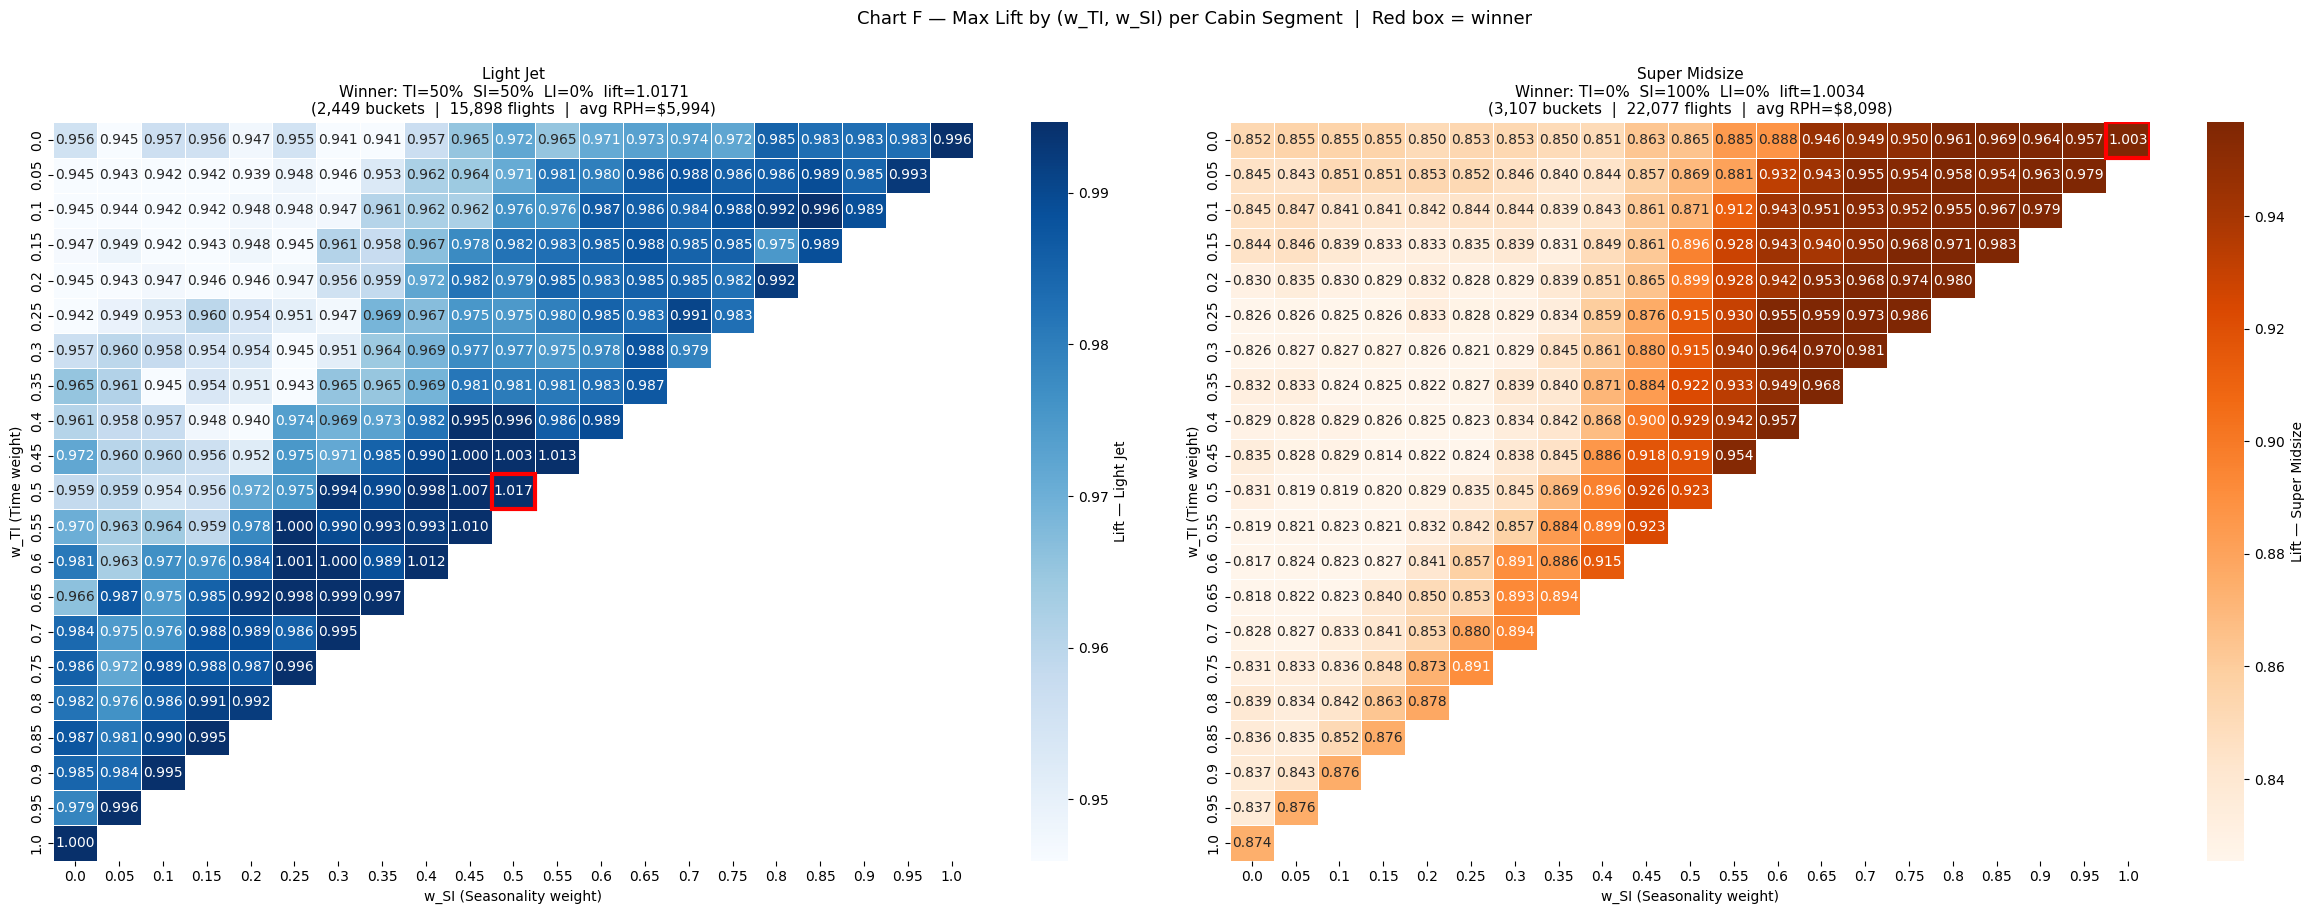

Saved: lift_heatmap_by_cabin.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
cmaps = {'Light Jet': 'Blues', 'Super Midsize': 'Oranges'}

for ax, (seg_name, sr) in zip(axes, seg_results.items()):
    res = sr['results']
    w   = sr['winner']
    pivot = res.pivot_table(values='lift', index='w_TI', columns='w_SI', aggfunc='max')
    vlo, vhi = res.lift.quantile(0.10), res.lift.quantile(0.90)
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap=cmaps[seg_name],
                linewidths=0.4, ax=ax,
                cbar_kws={'label': f'Lift — {seg_name}'},
                vmin=vlo, vmax=vhi)

    # Highlight winner cell
    w_ti_vals = list(pivot.index); w_si_vals = list(pivot.columns)
    try:
        ri = min(range(len(w_ti_vals)), key=lambda i: abs(w_ti_vals[i] - w.w_TI))
        ci = min(range(len(w_si_vals)), key=lambda i: abs(w_si_vals[i] - w.w_SI))
        ax.add_patch(plt.Rectangle((ci, ri), 1, 1, fill=False, edgecolor='red', lw=3))
    except: pass

    ax.set_title(
        f'{seg_name}\n'
        f'Winner: TI={w.w_TI:.0%}  SI={w.w_SI:.0%}  LI={w.w_LI:.0%}  '
        f'lift={w.lift:.4f}\n'
        f'({sr["n_buckets"]:,} buckets  |  {sr["n_flights"]:,} flights  |  '
        f'avg RPH=${sr["seg_avg_rph"]:,.0f})',
        fontsize=11
    )
    ax.set_xlabel('w_SI (Seasonality weight)', fontsize=10)
    ax.set_ylabel('w_TI (Time weight)', fontsize=10)

plt.suptitle('Chart F — Max Lift by (w_TI, w_SI) per Cabin Segment  |  Red box = winner',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('lift_heatmap_by_cabin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_heatmap_by_cabin.png')


---
### Chart G — Lift Distribution Comparison (All Combos per Segment)

These histograms show the **distribution of lift values across all 231 combos**  
for each segment. A narrow distribution means the choice of weights matters less;  
a wide distribution means the right weights make a big difference.

The **green dashed line** marks the winner. The **blue dash-dot** marks the baseline (60/30/10).


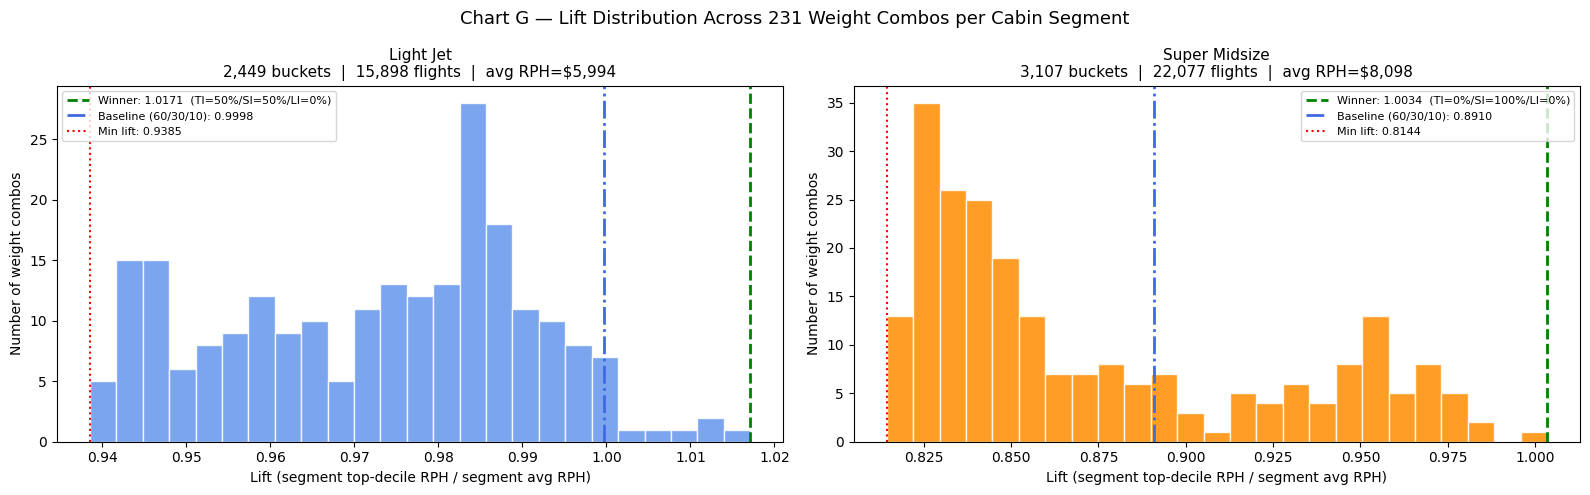

Saved: lift_dist_by_cabin.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
palette = {'Light Jet': 'cornflowerblue', 'Super Midsize': 'darkorange'}

for ax, (seg_name, sr) in zip(axes, seg_results.items()):
    res = sr['results']
    w   = sr['winner']
    bl  = sr['baseline']

    ax.hist(res.lift, bins=25, color=palette[seg_name], edgecolor='white', alpha=0.85)
    ax.axvline(w.lift, color='green', ls='--', lw=2,
               label=f'Winner: {w.lift:.4f}  (TI={w.w_TI:.0%}/SI={w.w_SI:.0%}/LI={w.w_LI:.0%})')
    if bl is not None:
        ax.axvline(bl.lift, color='royalblue', ls='-.', lw=2,
                   label=f'Baseline (60/30/10): {bl.lift:.4f}')
    ax.axvline(res.lift.min(), color='red', ls=':', lw=1.5,
               label=f'Min lift: {res.lift.min():.4f}')

    ax.set_title(
        f'{seg_name}\n'
        f'{sr["n_buckets"]:,} buckets  |  {sr["n_flights"]:,} flights  |  '
        f'avg RPH=${sr["seg_avg_rph"]:,.0f}',
        fontsize=11
    )
    ax.set_xlabel('Lift (segment top-decile RPH / segment avg RPH)', fontsize=10)
    ax.set_ylabel('Number of weight combos', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Chart G — Lift Distribution Across 231 Weight Combos per Cabin Segment',
             fontsize=13)
plt.tight_layout()
plt.savefig('lift_dist_by_cabin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: lift_dist_by_cabin.png')


---
### Chart H — Winner Weight Comparison: LJ vs SMID vs Baseline

A direct visual comparison of the optimal weights for each segment  
against the current baseline (60%/30%/10%).

| Bar group | Meaning |
|-----------|---------|
| **w_TI** | How much of the score comes from Time Index |
| **w_SI** | How much comes from Seasonality Index |
| **w_LI** | How much comes from Loyalty Index |

> If LJ and SMID show very different optimal weights, it confirms that  
> a single set of weights for the whole network is a compromise —  
> and cabin-specific weights would improve precision.


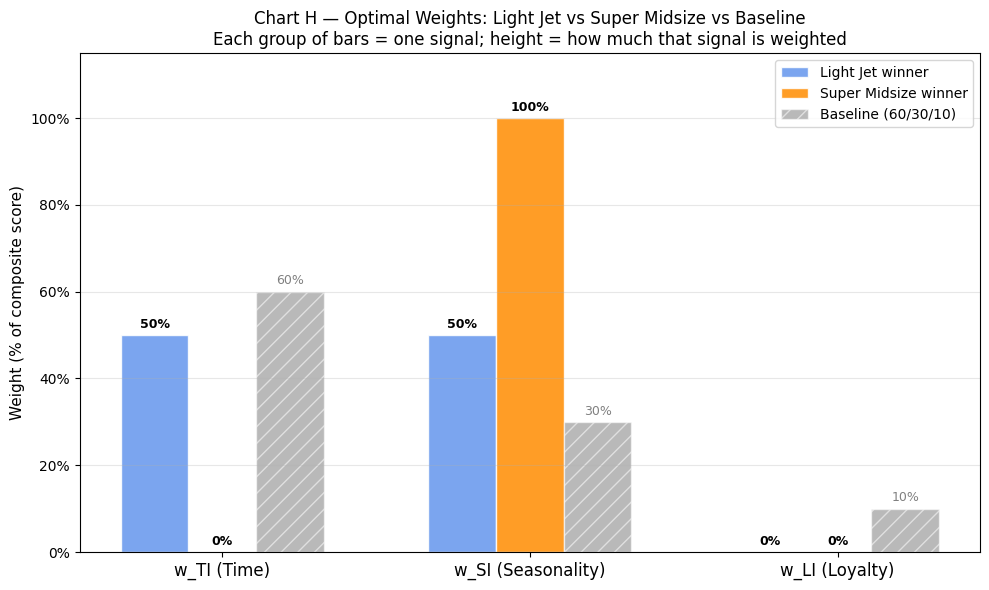

Saved: winner_weights_by_cabin.png


In [25]:
labels     = ['w_TI (Time)', 'w_SI (Seasonality)', 'w_LI (Loyalty)']
x          = np.arange(len(labels))
width      = 0.22
seg_colors = {'Light Jet': 'cornflowerblue', 'Super Midsize': 'darkorange'}
baseline_w = list(BASELINE_W)

fig, ax = plt.subplots(figsize=(10, 6))

for i, (seg_name, sr) in enumerate(seg_results.items()):
    w    = sr['winner']
    vals = [w.w_TI, w.w_SI, w.w_LI]
    bars = ax.bar(x + (i - 0.5)*width, vals, width,
                  label=f'{seg_name} winner',
                  color=seg_colors[seg_name], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Baseline bars
offset = len(seg_results) * width - width * 0.5
base_bars = ax.bar(x + offset, baseline_w, width,
                   label='Baseline (60/30/10)', color='grey', alpha=0.55,
                   edgecolor='white', hatch='//')
for bar, val in zip(base_bars, baseline_w):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.0%}', ha='center', va='bottom', fontsize=9, color='grey')

ax.set_xticks(x + width * 0.5)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Weight (% of composite score)', fontsize=11)
ax.set_title('Chart H — Optimal Weights: Light Jet vs Super Midsize vs Baseline\n'
             'Each group of bars = one signal; height = how much that signal is weighted',
             fontsize=12)
ax.set_ylim(0, 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('winner_weights_by_cabin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: winner_weights_by_cabin.png')


---
### Segment Summary Table

A single table comparing the key numbers across both segments and the full network.  
This is the **board-ready summary** for the cabin-level analysis.

| Row | Description |
|-----|-------------|
| **Flights / Buckets** | Scale of data for this segment |
| **Segment avg RPH** | The benchmark RPH for this cabin |
| **Optimal w_TI / w_SI / w_LI** | The winning weight mix |
| **Winner Lift** | How much better the top-decile is vs segment avg |
| **Top-decile RPH** | Absolute RPH of the top-scored windows |
| **Baseline Lift** | Lift using current 60/30/10 weights |
| **Baseline Rank** | Where the current weights rank among all 231 combos |
| **Improvement** | % lift gain from optimised weights vs baseline |


In [26]:
rows = []
for seg_name, sr in seg_results.items():
    w  = sr['winner']
    bl = sr['baseline']
    bl_lift = bl.lift if bl is not None else None
    bl_rank = sr['results'][sr['bm_mask']].index[0]+1 if bl is not None else None
    impr    = f"+{(w.lift - bl_lift)/bl_lift*100:.2f}%" if bl_lift else 'n/a'
    rows.append({
        'Segment'         : seg_name,
        'Flights'         : f"{sr['n_flights']:,}",
        'Buckets'         : f"{sr['n_buckets']:,}",
        'Segment avg RPH' : f"${sr['seg_avg_rph']:,.0f}",
        'Optimal w_TI'    : f"{w.w_TI:.0%}",
        'Optimal w_SI'    : f"{w.w_SI:.0%}",
        'Optimal w_LI'    : f"{w.w_LI:.0%}",
        'Winner Lift'     : f"{w.lift:.4f}",
        'Top-decile RPH'  : f"${w.top_decile_rph:,.0f}",
        'Spearman'        : f"{w.spearman:.3f}",
        'Verdict'         : sr['verdict_label'],
        'Baseline Lift'   : f"{bl_lift:.4f}" if bl_lift else 'n/a',
        'Baseline Rank'   : f"#{bl_rank}" if bl_rank else 'n/a',
        'Improvement'     : impr,
    })

summary = pd.DataFrame(rows).set_index('Segment')
print('SEGMENT OPTIMISATION SUMMARY')
print('(Transposed so each column = one segment)')
print()
display(summary.T)


SEGMENT OPTIMISATION SUMMARY
(Transposed so each column = one segment)



Segment,Light Jet,Super Midsize
Flights,"15,898","22,077"
Buckets,"2,449","3,107"
Segment avg RPH,"$5,994","$8,098"
Optimal w_TI,50%,0%
Optimal w_SI,50%,100%
Optimal w_LI,0%,0%
Winner Lift,1.0171,1.0034
Top-decile RPH,"$6,096","$8,126"
Spearman,-0.097,-0.211
Verdict,WINNER (Fallback: Spearman >= -0.130),WINNER (Fallback: Spearman >= -0.291)
